Following this:
 https://debuggercafe.com/image-deblurring-using-convolutional-neural-networks-and-deep-learning/

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb
import seaborn as sns

import cv2
import os
from tqdm import tqdm

# Image Deblurring using CNN


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kwentar/blur-dataset")

print("Path to dataset files:", path)

e:\Rijan_Shrestha\AI\AI Works\ai_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\nissa\.cache\kagglehub\datasets\kwentar\blur-dataset\versions\2


In [3]:
filepath = r"C:\Users\nissa\.cache\kagglehub\datasets\kwentar\blur-dataset\versions\2"
print(filepath)

C:\Users\nissa\.cache\kagglehub\datasets\kwentar\blur-dataset\versions\2


In [4]:
os.makedirs(filepath + '/gaussian_blurred', exist_ok=True)
src_dir = filepath + '/sharp'
images = os.listdir(src_dir)
dst_dir = filepath + '/gaussian_blurred'

len(images)

350

In [5]:
images[0]

'0_IPHONE-SE_S.JPG'

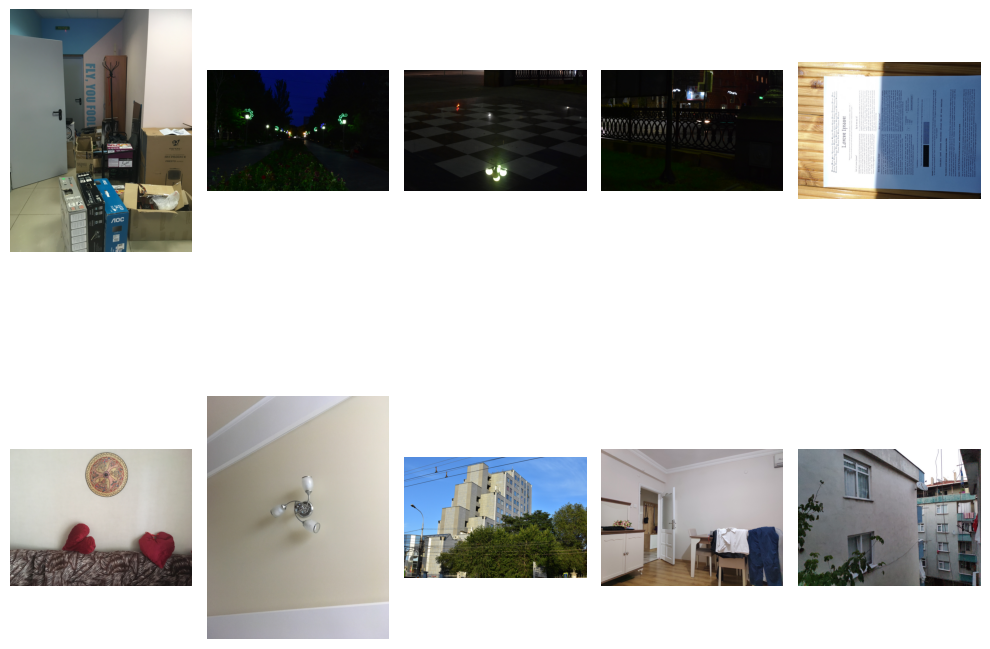

In [6]:
from PIL import Image

plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(2, 5, i+1)
    img = Image.open(src_dir + '/' + images[i])
    plt.imshow(img)
    plt.axis('off')
plt.tight_layout()
plt.show()



In [7]:
for i, img in tqdm(enumerate(images), total = len(images)):
    img = cv2.imread(src_dir + '/' + images[i], cv2.IMREAD_COLOR)
    blur = cv2.GaussianBlur(img, (31, 31), 0)
    cv2.imwrite(dst_dir + "/" + images[i], blur)

print("Done")

100%|██████████| 350/350 [00:10<00:00, 34.46it/s]

Done


(np.float64(-0.5), np.float64(1535.5), np.float64(2047.5), np.float64(-0.5))

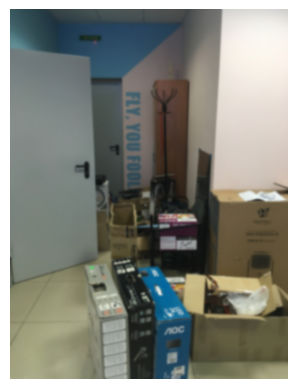

In [8]:
from PIL import Image
img = Image.open(dst_dir + "/" + images[0])
plt.imshow(img)
plt.axis('off')

## Visualizing the Blurred Images


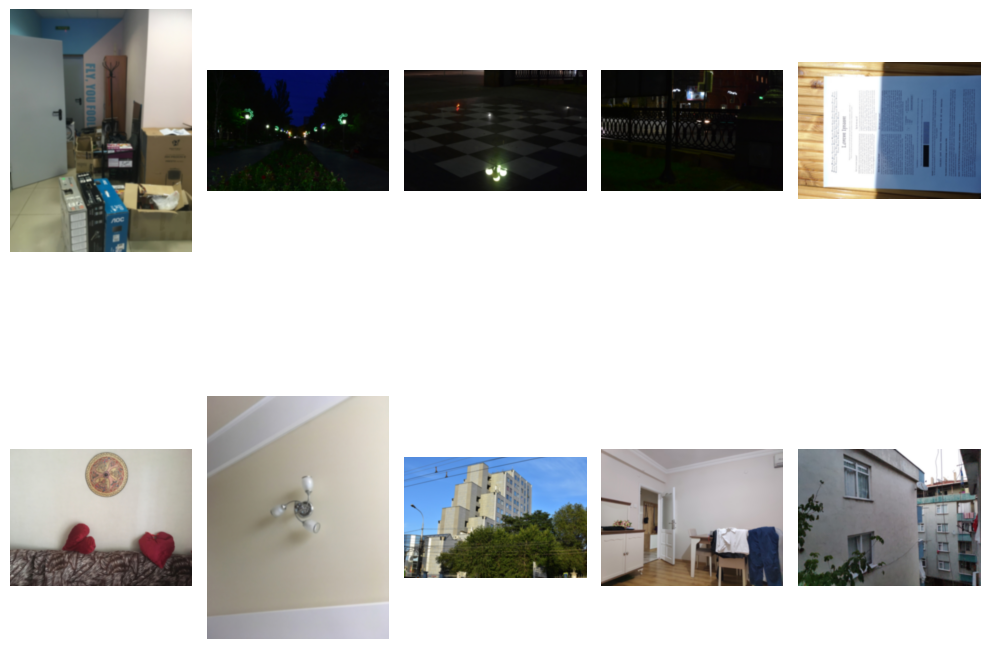

In [9]:
from PIL import Image

plt.figure(figsize=(10, 10))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = Image.open(dst_dir + "/" + images[i])
    plt.imshow(img)
    plt.axis("off")
plt.tight_layout()
plt.show()

# Deblurring the Image


In [10]:
import numpy as np
import os
import matplotlib.pyplot as plt
import glob
import cv2
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import time
import argparse

from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import transforms
from torchvision.utils import save_image
from sklearn.model_selection import train_test_split


In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size = 2
device

'cuda'

In [12]:
def save_decoded_image(img, name):
    img = img.view(img.size(0), 3, 224, 224)
    save_image(img, name)

In [13]:
saved_dir = filepath + "/saved_images"
os.makedirs(saved_dir, exist_ok = True)

In [14]:
# Defining the dataloader
class DeblurDataset(Dataset):
    def __init__(self, blur_paths, sharp_paths = None, transforms = None ):
        self.X = blur_paths
        self.y = sharp_paths
        self.transforms = transforms

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, i):
        blur_image = cv2.imread(filepath + "/gaussian_blurred/" + self.X[i])

        if self.transforms:
            blur_image = self.transforms(blur_image)
        
        if self.y:
            sharp_image = cv2.imread(filepath + "/sharp/" + self.y[i])
            sharp_image = self.transforms(sharp_image)
            return (blur_image, sharp_image)
        else:
            return blur_image
        


In [15]:
#Defining the transform 

transform = transforms.Compose([
    transforms.ToPILImage(), 
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [16]:
# Making list of all file paths
gauss_blur = os.listdir(dst_dir)
gauss_blur.sort()

sharp = os.listdir(src_dir)
sharp.sort()

x_blur = []
for i in range(len(gauss_blur)):
    x_blur.append(gauss_blur[i])

y_sharp = []

for i in range(len(sharp)):
    y_sharp.append(sharp[i])


In [17]:
(x_train, x_val, y_train, y_val) = train_test_split(x_blur, y_sharp, test_size = 0.25)

print(f"Train data instances: {len(x_train)}")
print(f"Validation data instances: {len(x_val)}")

Train data instances: 262
Validation data instances: 88


In [18]:
train_data = DeblurDataset(x_train, y_train, transforms = transform)
val_data = DeblurDataset(x_val, y_val, transforms = transform)

train_loader = DataLoader(train_data, batch_size = batch_size, shuffle = True )
val_loader = DataLoader(val_data, batch_size = batch_size, shuffle = False)

In [19]:
class DeblurCNN(nn.Module):
    def __init__(self):
        super(DeblurCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=9, padding =2 )
        self.conv2 = nn.Conv2d(64, 32, kernel_size = 1, padding = 2)
        self.conv3 = nn.Conv2d(32, 3, kernel_size = 5, padding = 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.conv3(x)

        return x

model = DeblurCNN().to(device)
print(model)

DeblurCNN(
  (conv1): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)


In [20]:
model.parameters()

<generator object Module.parameters at 0x000001DF0D273680>

In [21]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001 )

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode = 'min', 
    patience = 5, 
    factor = 0.5, 
)


In [22]:

#Function for training the model
from tqdm import tqdm

def fit(model, dataLoader, epoch):
    model.train()
    running_loss = 0.0
    for i, data in tqdm(enumerate(dataLoader), total = int(len(train_data)/batch_size)):
        blur_image = data[0]
        sharp_image = data[1]

        blur_image = blur_image.to(device)
        sharp_image = sharp_image.to(device)
        
        optimizer.zero_grad()
        outputs = model(blur_image)
        
        loss = criterion(outputs, sharp_image)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()
    
    train_loss = running_loss/len(dataLoader.dataset)
    print(f"Train Loss: {train_loss: .5f}")

    return train_loss


In [23]:
def validate(model, dataloader, epoch):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for i, data in tqdm(enumerate(dataloader), total = int(len(dataloader.dataset)/batch_size)):
            blur_image = data[0]
            sharp_image = data[1]

            blur_image = blur_image.to(device)
            sharp_image = sharp_image.to(device)

            outputs = model(blur_image)
            loss = criterion(outputs, sharp_image)

            running_loss += loss.item()

            if epoch == 0 and i == int((len(val_data)/dataloader.batch_size) - 1):
                save_decoded_image(sharp_image.cpu().data, name = filepath + f"/saved_images/sharp{epoch}.jpg")   
                save_decoded_image(blur_image.cpu().data, name = filepath + f"/saved_images/blur{epoch}.jpg")
            
            if i == int((len(val_data)/dataloader.batch_size) - 1):
                save_decoded_image(outputs.cpu().data, name = filepath + f"/saved_images/val_deblurred{epoch}.jpg")
        
        val_loss = running_loss/len(dataloader.dataset)
        print(f"Validation Loss = {val_loss:.5f}")
    
    return val_loss 

        

In [24]:
import time 

train_loss = []
val_loss = []
start = time.time()
epochs = 40

# Training
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}")
    train_epoch_loss = fit(model, train_loader, epoch)
    val_epoch_loss = validate(model, val_loader, epoch)
    train_loss.append(train_epoch_loss)
    val_loss.append(val_epoch_loss)
    scheduler.step(val_epoch_loss)

end = time.time()

print(f"Time Elapsed: {end - start}")


Epoch 1


100%|██████████| 131/131 [00:18<00:00,  6.95it/s]


Train Loss:  0.01087


100%|██████████| 44/44 [00:06<00:00,  6.77it/s]


Validation Loss = 0.00274
Epoch 2


...

Validation Loss = 0.00020
Epoch 40


100%|██████████| 131/131 [00:17<00:00,  7.52it/s]


Train Loss:  0.00025


100%|██████████| 44/44 [00:05<00:00,  8.15it/s]

Validation Loss = 0.00020
Time Elapsed: 937.5379273891449


Saving Model... 


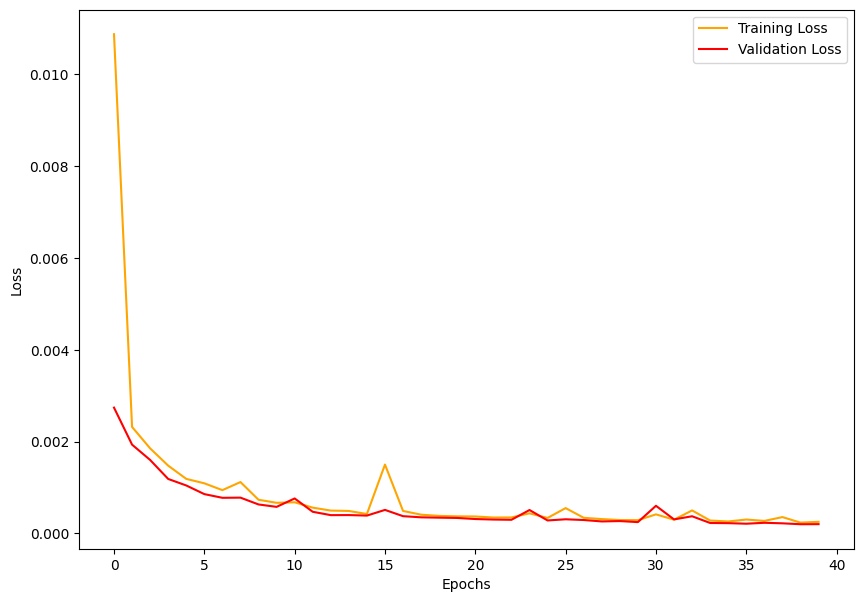

In [25]:
plt.figure(figsize = (10, 7))
plt.plot(train_loss, color = 'orange', label = 'Training Loss')
plt.plot(val_loss, color = 'red', label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig("loss_1.png")

print("Saving Model... ")
torch.save(model.state_dict(), filepath + 'model.pth')

In [26]:
train_data[0][0].size()

torch.Size([3, 224, 224])

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

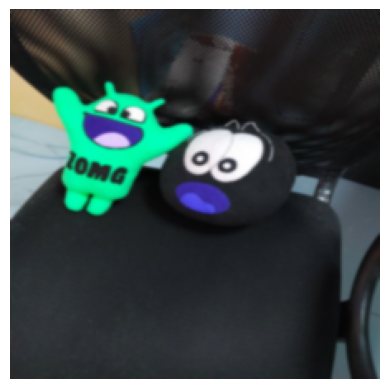

In [27]:
plt.imshow(train_data[10][0].permute(1, 2, 0))
plt.axis('off')

In [28]:
img = train_data[10][0].to(device)
pred = model(img)
pred.shape

torch.Size([3, 224, 224])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.14329664..1.1268641].


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

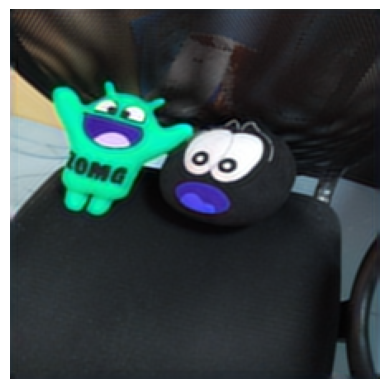

In [29]:
plt.imshow(pred.detach().permute(1, 2 ,0).cpu())
plt.axis('off')